In [ ]:
#install required packages
!pip install xgboost -q

In [ ]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor


In [ ]:
#Loading the dataset
df = pd.read_csv('charging_ev_and_grid_optimization_dataset.csv')

print(df.shape)

df.head()

(8354, 27)


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [ ]:
#Preprocess the data
df = df.drop_duplicates()

print("Missing values")

print(df.isnull().sum())

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.info()
df.describe()

Missing values
timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0
arrival_time              0
charging_start_time       0
charging_end_time         0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
charging_duration         0
queue_length              0
station_load              0
electricity_price         0
renewable_energy_ratio    0
traffic_density           0
weather_condition         0
day_of_week               0
time_slot                 0
charging_demand           0
assigned_charger_id       0
charging_priority         0
optimization_reward       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  ----

,timestamp,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,2025-02-13 12:07:30,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
min,2025-01-01 00:00:00,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,2025-01-22 18:03:45,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,2025-02-13 12:07:30,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,2025-03-07 06:11:15,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,2025-03-29 00:15:00,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434
std,NaN,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940


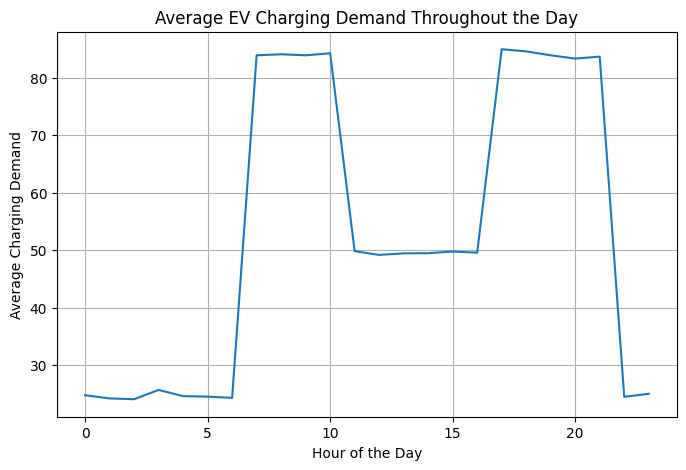

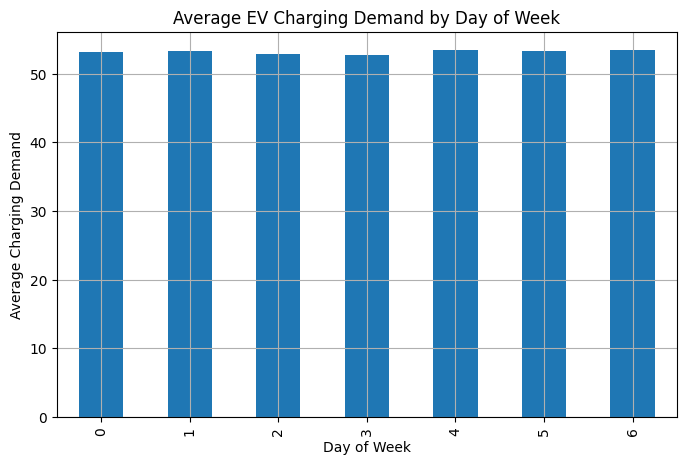

In [ ]:
#Expolatory data analysis
hourly_demand = df.groupby(df['timestamp'].dt.hour)['charging_demand'].mean()

daily_demand = df.groupby(df['timestamp'].dt.day_of_week)['charging_demand'].mean()
#Graph 1
plt.figure(figsize=(8,5))

hourly_demand.plot()

plt.title('Average EV Charging Demand Throughout the Day')

plt.xlabel('Hour of the Day')

plt.ylabel('Average Charging Demand')

plt.grid(True)

plt.show()

#Graph 2
plt.figure(figsize=(8,5))

daily_demand.plot(kind='bar')

plt.title('Average EV Charging Demand by Day of Week')

plt.xlabel('Day of Week')

plt.ylabel('Average Charging Demand')

plt.grid(True)

plt.show()

In [ ]:
#Feature engineering
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

df['is_weekend'] = df['day_of_week'].isin( ['Saturday', 'Sunday']).astype(int)
df['peak_hour'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19,20] else 0)

In [ ]:
#Encode columns
label_columns = [
    'weather_condition',
    'day_of_week',
    'location_type',
    'vehicle_type',
    'traffic_density',
    'is_weekend'
]

encoders = {}

for col in label_columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoders[col] = le

# K-Means

In [ ]:
# K-Means

persona_features = [
    'charging_duration',
    'energy_consumed_kWh',
    'initial_soc',
    'final_soc',
    'waiting_time',
    'charging_power_kW',
    'hour',
    'location_type',
    'is_weekend',
    'vehicle_type'
]

persona_df = df[persona_features]
x = StandardScaler()
y_means = x.fit_transform(persona_df)


In [ ]:
# Elbow method
inertia = []
for k in range(2,10):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(y_means)
  inertia.append(km.inertia_)



In [ ]:
inertia

[71989.44911034008,
 65884.56122329492,
 60107.35293106835,
 55110.65353282225,
 52491.07480910002,
 50859.07298256966,
 48747.20523078937,
 47378.72590242338]

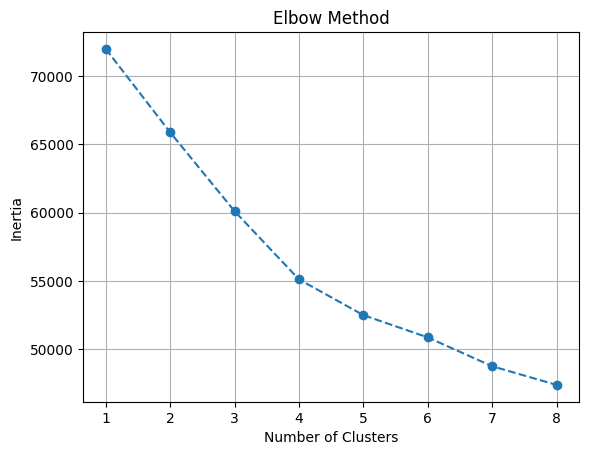

In [ ]:
# Plot Elbow graph
#plt.figure(figsize=(8,5))

plt.plot(range(1,9), inertia, marker='o', linestyle='--')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.grid(True)

plt.show()

In [ ]:
# Final K- Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df['persona'] = kmeans.fit_predict(y_means)
df['persona']

,persona
0,1
1,1
2,1
3,1
4,3
...,...
8349,2
8350,1
8351,3
8352,0


In [ ]:
df['persona'].value_counts()

,count
persona,
1,4001
3,1926
0,1867
2,560


In [ ]:
persona_summary = df.groupby('persona')[[
    'charging_duration',
    'energy_consumed_kWh',
    'initial_soc',
    'final_soc',
    'waiting_time',
    'charging_power_kW',
    'hour',
    'location_type',
    'is_weekend',
    'vehicle_type'
]].mean()

persona_summary

,charging_duration,energy_consumed_kWh,initial_soc,final_soc,waiting_time,charging_power_kW,hour,location_type,is_weekend,vehicle_type
persona,,,,,,,,,,
0,139.314951,35.289505,36.706225,99.040540,9.601500,22.956615,11.392073,0.509909,1.000000,0.995179
1,120.930745,32.055391,38.786493,99.101686,9.479880,24.002000,11.434391,0.491377,0.000000,0.987503
2,35.166186,25.661489,34.984820,88.675473,10.083929,45.641071,12.067857,0.505357,0.223214,1.037500
3,378.621469,61.247475,24.653700,99.563335,9.387850,11.988058,11.563863,0.512461,0.163032,1.020249


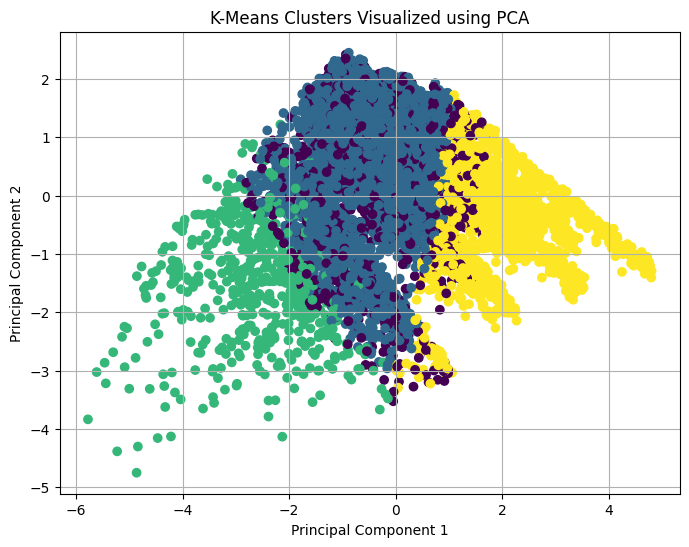

In [ ]:
# PCA Visualization

from sklearn.decomposition import PCA

# Reduce dimentions from multiple features to 2 dimentions

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(y_means)

# Create a dataframe for visualization
pca_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])
pca_df['persona'] = df['persona']

# Add cluster labels
pca_df['persona'] = df['persona']

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['persona'], cmap='viridis')
plt.title('K-Means Clusters Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


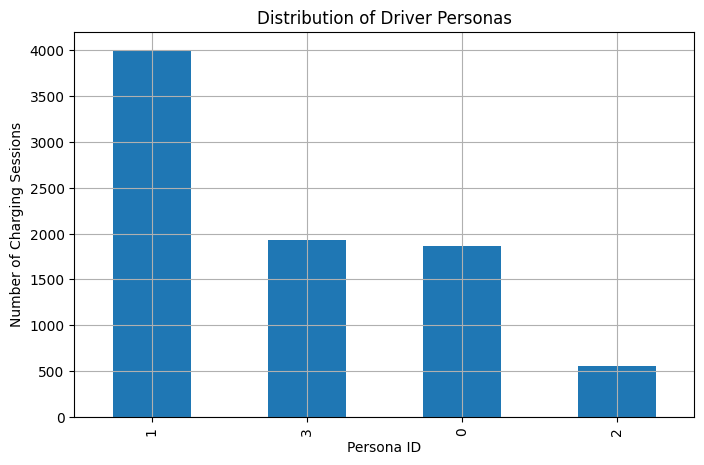

In [ ]:
# Persona Distribution graph
plt.figure(figsize=(8,5))

df['persona'].value_counts().plot(kind='bar')

plt.title('Distribution of Driver Personas')

plt.xlabel('Persona ID')

plt.ylabel('Number of Charging Sessions')

plt.grid(True)

plt.show()

In [ ]:
# Random Forest

features = [
    'hour',
    'queue_length',
    'initial_soc',
    'traffic_density',
    'weather_condition',
    'day_of_week',
    'persona',
    'location_type',
    'vehicle_type',
    'is_weekend'
]

x = df[features]
y = df['charging_demand']

# Spliting the data
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size = 0.2,random_state = 42)

rf = RandomForestRegressor(n_estimators = 100,max_depth = 10,random_state = 42)

# Training random forest
rf.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, random_state=42)

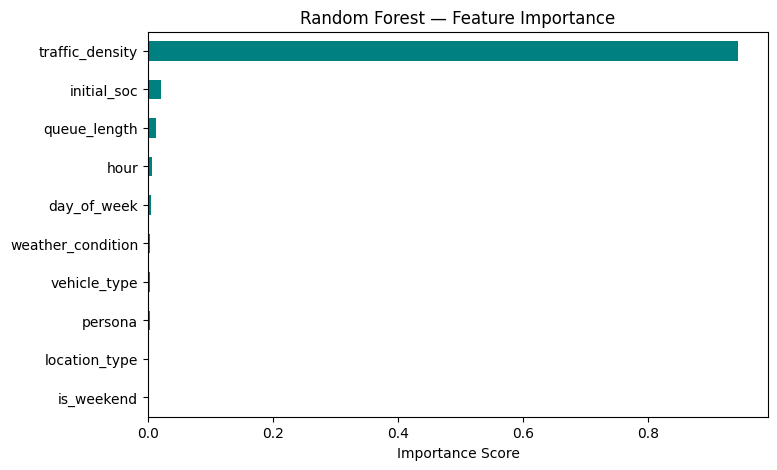

In [ ]:
# Feature Importance
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='barh', color='teal')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# XGBoost
xgb = XGBRegressor(n_estimators = 100,learning_rate = 0.1,max_depth = 6, random_state = 42)

#Training XGBoost
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Model Comparison using metrics

results = []
models = {
    'Random Forest':rf,
    'XGBoost':xgb
}

for name, model in models.items():
  pred = model.predict(x_test)
  mae = mean_absolute_error(y_test, pred)
  rmse = root_mean_squared_error(y_test, pred)
  r2 = r2_score(y_test, pred)

  results.append([name, mae, rmse, r2])


results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df






,Model,MAE,RMSE,R2
0,Random Forest,7.860933,9.551903,0.882118
1,XGBoost,7.925847,9.644410,0.879824


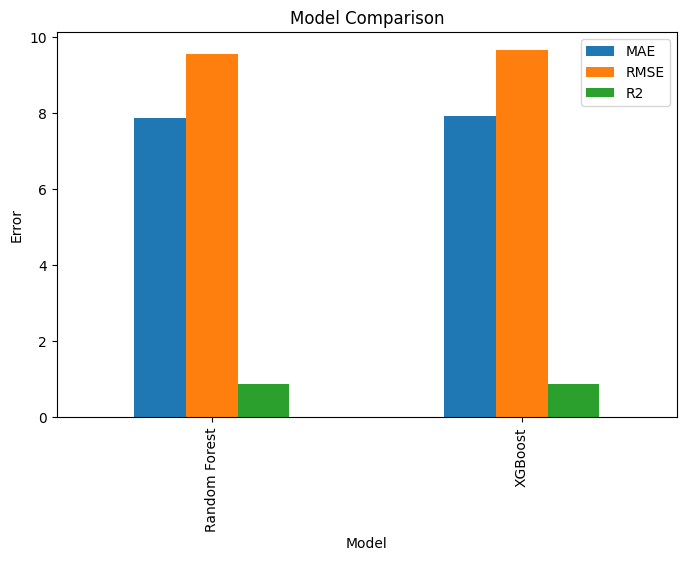

In [ ]:
# Graph
comparison = results_df[['Model', 'MAE', 'RMSE', 'R2']]

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Comparison')

plt.ylabel('Error')

plt.show()

In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x, y, cv=5, scoring='r2')
print("Cross-Validation Scores:", scores)
print("Mean R2 Score:", scores.mean())

Cross-Validation Scores: [0.88633156 0.88238039 0.88017578 0.88563473 0.88667209]
Mean R2 Score: 0.8842389103578085


In [ ]:
# Actual vs Predicted Analysis
# for random forest

rf_pred = rf.predict(x_test)

comparison_rf = pd.DataFrame({'Actual': y_test, 'Predicted': rf_pred})
comparison_rf.head(10)



,Actual,Predicted
3532,85.721649,81.674105
8239,65.222312,82.829545
4586,78.746789,80.963380
2795,17.950835,23.787035
5379,24.736213,21.520216
5903,68.854093,51.116845
1454,39.000704,30.078615
6282,103.212740,84.571927
743,103.587424,84.133511
1168,19.429369,24.307039


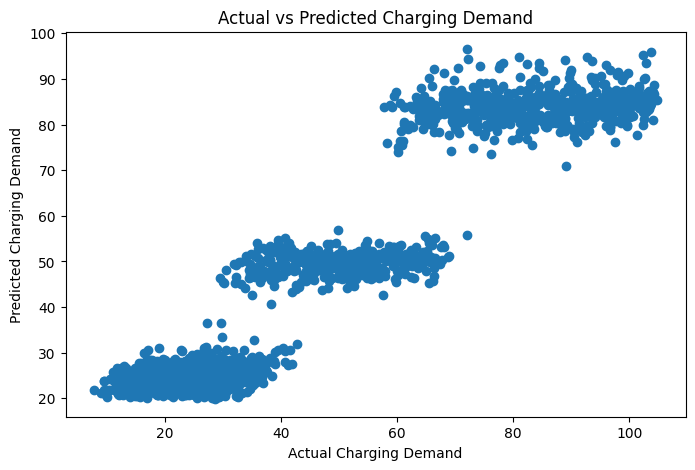

In [ ]:
# Graph
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Charging Demand')

plt.ylabel('Predicted Charging Demand')

plt.title('Actual vs Predicted Charging Demand')

plt.show()